**Hospital Dataset Challenge**

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
from google.colab import files

uploaded = files.upload()

Saving healthcare_dataset.csv to healthcare_dataset.csv


In [21]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [22]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("Columns:")
print(df.columns.tolist())

df.info()

Number of Rows: 600
Number of Columns: 7
Columns:
['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition', 'Admission_Type', 'Hospital']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         600 non-null    object
 1   Age                600 non-null    int64 
 2   Gender             600 non-null    object
 3   Blood_Type         600 non-null    object
 4   Medical_Condition  600 non-null    object
 5   Admission_Type     600 non-null    object
 6   Hospital           600 non-null    object
dtypes: int64(1), object(6)
memory usage: 32.9+ KB


In [23]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
Patient_ID           0
Age                  0
Gender               0
Blood_Type           0
Medical_Condition    0
Admission_Type       0
Hospital             0
dtype: int64


In [24]:
ages = df["Age"].dropna().head(500)

print(ages)

print("\nNumber of Patients:", len(ages))

0      89
1      55
2      20
3      45
4      59
       ..
495    48
496    85
497    21
498    51
499    47
Name: Age, Length: 500, dtype: int64

Number of Patients: 500


In [25]:
print("Average Age:", ages.mean())
print("Minimum Age:", ages.min())
print("Maximum Age:", ages.max())

print(ages.describe())

Average Age: 47.916
Minimum Age: 5
Maximum Age: 94
count    500.000000
mean      47.916000
std       21.784538
min        5.000000
25%       31.000000
50%       47.000000
75%       63.000000
max       94.000000
Name: Age, dtype: float64


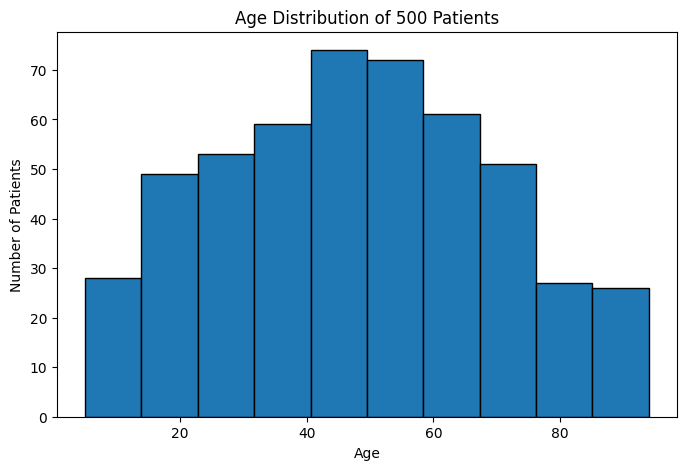

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    ages,
    bins=10,
    edgecolor="black"
)

plt.title("Age Distribution of 500 Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [27]:
age_groups = pd.cut(
    ages,
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    labels=[
        "0-10",
        "11-20",
        "21-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71-80",
        "81-90",
        "91-100"
    ],
    include_lowest=True
)

print(age_groups)

0      81-90
1      51-60
2      11-20
3      41-50
4      51-60
       ...  
495    41-50
496    81-90
497    21-30
498    51-60
499    41-50
Name: Age, Length: 500, dtype: category
Categories (10, object): ['0-10' < '11-20' < '21-30' < '31-40' ... '61-70' < '71-80' < '81-90' <
                          '91-100']


In [28]:
age_group_counts = age_groups.value_counts().sort_index()

print("Number of Patients in Each Age Group:")

print(age_group_counts)

Number of Patients in Each Age Group:
Age
0-10      18
11-20     42
21-30     60
31-40     69
41-50     80
51-60     87
61-70     57
71-80     54
81-90     18
91-100    15
Name: count, dtype: int64


In [29]:
most_common_group = age_group_counts.idxmax()

highest_count = age_group_counts.max()

print("Most Common Age Group:", most_common_group)
print("Number of Patients:", highest_count)

Most Common Age Group: 51-60
Number of Patients: 87


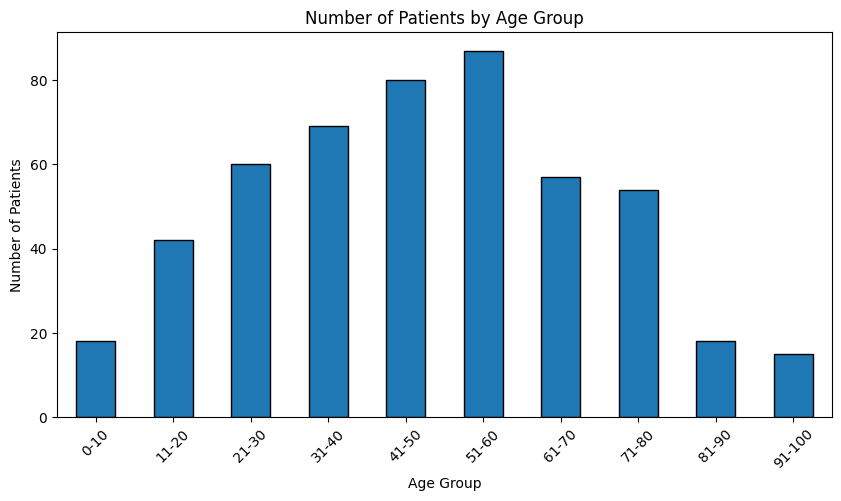

In [30]:
plt.figure(figsize=(10, 5))

age_group_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Number of Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

In [31]:
print("===== HOSPITAL PATIENT AGE ANALYSIS =====")

print("Total Patients Analysed:", len(ages))

print("Average Age:", round(ages.mean(), 2))

print("Youngest Patient:", ages.min())

print("Oldest Patient:", ages.max())

print("Most Common Age Group:", most_common_group)

print(
    "Patients in Most Common Group:",
    highest_count
)

===== HOSPITAL PATIENT AGE ANALYSIS =====
Total Patients Analysed: 500
Average Age: 47.92
Youngest Patient: 5
Oldest Patient: 94
Most Common Age Group: 51-60
Patients in Most Common Group: 87
